# PASO 1: CARGA Y FILTRADO BIG DATA CON DASK

Para evitar saturar la memoria RAM con el archivo masivo de toda España, utilizamos Dask. Dask escanea el archivo sin cargarlo entero y construye un grafo de tareas con nuestras reglas (filtrar solo "Sevilla" y seleccionar las columnas clave). Solo al ejecutar .compute(), el sistema paraleliza el trabajo entre los núcleos de la CPU, procesando los datos por bloques de forma ultraeficiente y devolviéndonos un DataFrame ligero y listo para entrenar a nuestra IA.

In [8]:
import dask.dataframe as dd
import pandas as pd

# 1. Carga con Dask

df_espana_dask = dd.read_csv('../data/raw/spanish_houses.csv', dtype=str)

# 2. Filtrado y Selección de Columnas en Paralelo

df_sevilla_dask = df_espana_dask[df_espana_dask['loc_zone'].str.contains('sevilla', case=False, na=False)]

columnas_modelo = [
    'price', 'm2_real', 'room_num', 'bath_num', 'loc_city', 'loc_district',
    'house_type', 'balcony', 'garage', 'swimming_pool', 'terrace', 'storage_room', 
    'lift', 'garden', 'condition'
]

df_modelo_dask = df_sevilla_dask[columnas_modelo]

# 3. Ejecución

df_modelo = df_modelo_dask.compute(scheduler='threads')

# Volvemos a convertir el índice para que empiece en 0

df_modelo = df_modelo.reset_index(drop=True)

print(f"Viviendas extraídas a la memoria local: {df_modelo.shape[0]}")
display(df_modelo.head())

Viviendas extraídas a la memoria local: 5076


,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,condition
0,212000,302,5,3,Guillena,<NA>,Chalet pareado,0,plaza de garaje incluida en el precio,1,1,0,<NA>,1,<NA>
1,280000,500,5,3,Almadén de la Plata,"Calle las Granadinas, 20",Casa o chalet independiente,1,plaza de garaje incluida en el precio,1,1,1,<NA>,0,segunda mano/buen estado
2,50000,200,2,1,El Pedroso,"Calle Yesca, 7",Casa de pueblo,0,<NA>,0,0,0,<NA>,0,segunda mano/para reformar
3,90000,200,3,1,Guadalcanal,"Calle Vicente Amigo, 42",Casa de pueblo,1,plaza de garaje incluida en el precio,0,0,1,<NA>,0,segunda mano/buen estado
4,125000,120,4,3,Castilblanco de los Arroyos,"Calle Valdes Leal, 8",Piso,1,<NA>,0,1,0,0,0,segunda mano/buen estado


# PASO 2: LIMPIEZA Y PREPARACIÓN DE DATOS

Aquí nos encargamos de limpiar el dataset usando Pandas. Como el modelo puede dar errores por los tipos de formato, tenemos que arreglar aquellos "textos trampa" y borrar las filas que se han quedado sin precio o sin metros. Además, creamos datos nuevos como el precio por metro cuadrado y agrupamos los tipos de casas para que el modelo no se disperse con tantas categorías. El motivo de hacer todo esto es que por muy bueno que sea el algoritmo, si le metemos datos sucios o inconsistentes, nos va a devolver predicciones inútiles.

In [9]:
# 1. Sustituimos las frases "sin habitación" o "sin baños" por un "0" para no leer letras.

df_modelo['room_num'] = df_modelo['room_num'].astype(str).replace('sin habitación', '0')
df_modelo['bath_num'] = df_modelo['bath_num'].astype(str).replace('sin baños', '0')

# 2. Forzamos el formato numérico 
columnas_numericas = ['price', 'm2_real', 'room_num', 'bath_num']
for col in columnas_numericas:
    # Primero limpiamos las comas en un texto temporal
    texto_limpio = df_modelo[col].astype(str).str.replace(',', '.')
    # Extraemos solo los números
    solo_numeros = texto_limpio.str.extract(r'(\d+\.?\d*)')[0]
    # Sobrescribimos la columna entera cambiándole el tipo de dato a numérico
    df_modelo[col] = pd.to_numeric(solo_numeros, errors='coerce')

# 3. Borramos los pisos que se han quedado sin Precio o Metros 
df_modelo = df_modelo.dropna(subset=['price', 'm2_real'])

# Mapeo (Creamos nueva variable precio por metro cuadrado)
df_modelo['price_m2'] = df_modelo['price'] / df_modelo['m2_real']

# Unificar tipos de vivienda
df_modelo['house_type'] = df_modelo['house_type'].str.strip()
df_modelo['house_type'] = df_modelo['house_type'].replace({
    'Casa o chalet independiente': 'Casa o chalet',
    'Chalet pareado': 'Chalet',
    'Chalet adosado': 'Chalet',
    'Casa de pueblo': 'Casa',
    'Casa rural': 'Casa',
    'Casa terrera': 'Casa',
    'Torre': 'Piso',
})

# Ordenación (Ordenamos del piso más caro al más barato)
df_modelo = df_modelo.sort_values(by='price', ascending=False)

print(f"Limpieza terminada. Nos quedan {df_modelo.shape[0]} casas en perfecto estado.")
print("Vistazo a las columnas numéricas clave:")
display(df_modelo[['price', 'm2_real', 'price_m2', 'room_num', 'bath_num']].head())

Limpieza terminada. Nos quedan 5076 casas en perfecto estado.
Vistazo a las columnas numéricas clave:


,price,m2_real,price_m2,room_num,bath_num
3796,6273680,10391,6.037609e+02,1,1
2798,6000000,19882,3.017805e+02,6,4
972,3834000,426000,9.000000e+00,8,6
2395,3200000,2000,1.600000e+03,4,4
1066,3000000,2,1.500000e+06,8,6


# PASO 3: ELIMINACIÓN DE OUTLIERS

Aquí eliminamos del dataset las casas que se salen de lo normal, como propiedades de más de dos millones de euros, estudios imposibles de menos de 25 m², o errores tipográficos donde alguien puso un cero de más en el precio por metro cuadrado. El motivo es que los valores excepcionales distorsionan el aprendizaje del modelo; si intentamos que la IA aprenda a tasar una mansión de lujo y un estudio de barrio al mismo tiempo, perderá precisión en ambos. Recortando por arriba y por abajo nos aseguramos de que el modelo se entrene exclusivamente con el mercado inmobiliario real y cotidiano, volviéndose muchísimo más exacto en sus predicciones.

In [10]:
print(f"Casas antes de limpiar rarezas: {df_modelo.shape[0]}")

# 1. Filtro de Precios: Casas entre 30.000€ y 2.000.000€
df_modelo = df_modelo[(df_modelo['price'] >= 30000) & (df_modelo['price'] <= 2000000)]

# 2. Filtro de m2: Desde un micro-estudio (25m2) hasta un chalet enorme urbano (800m2)
df_modelo = df_modelo[(df_modelo['m2_real'] >= 25) & (df_modelo['m2_real'] <= 800)]

# 3. Filtro de precio por m² razonable (350 a 5000 €/m²)
df_modelo = df_modelo[(df_modelo['price_m2'] >= 350) & (df_modelo['price_m2'] <= 5000)]

print(f"Casas después de limpiar rarezas: {df_modelo.shape[0]}")

# Volvemos a mirar los resultados
display(df_modelo[['price', 'm2_real', 'room_num', 'bath_num']].head())
municipios_unicos = sorted(df_modelo["loc_city"].unique())

print(f"Total de municipios distintos: {len(municipios_unicos)}")
print(municipios_unicos)

Casas antes de limpiar rarezas: 5076
Casas después de limpiar rarezas: 4247


,price,m2_real,room_num,bath_num
2304,1355000,519,5,6
2227,1300000,670,5,4
1914,1250000,709,5,5
2824,1000000,500,4,1
4520,780300,782,1,1


Total de municipios distintos: 34
['Alanis', 'Albaida del Aljarafe', 'Almadén de la Plata', 'Arahal', 'Aznalcollar', 'Carrion de los Céspedes', 'Castilblanco de los Arroyos', 'Castilleja del Campo', 'Cazalla de la Sierra', 'Constantina', 'Dos Hermanas', 'El Castillo de las Guardas', 'El Garrobo', 'El Madroño', 'El Pedroso', 'El Real de la Jara', 'El Ronquillo', 'Espartinas', 'Gerena', 'Gines', 'Guadalcanal', 'Guillena', 'Huévar', 'La Puebla de los Infantes', 'Las Navas de la Concepcion', 'Mairena del Aljarafe', 'Olivares', 'Paradas', 'Pilas', 'San Juan de Aznalfarache', 'San Nicolas del Puerto', 'Sanlúcar la Mayor', 'Sevilla', 'Tomares']


# PASO 4: TRATAMIENTO DE NULOS Y VARIABLES BINARIAS

En este paso nos encargamos de traducir características clave a variables binarias. La columna que nos dice el estado de la casa viene en texto, así que la dividimos en dos variables numéricas nuevas y directas (1 si necesita reforma, 1 si es obra nueva) y borramos el texto viejo. Luego aplicamos lógica de negocio a los "extras" (piscina, ascensor, balcón...): si el anuncio original no mencionaba nada, asumimos de forma segura que no lo tiene y le plantamos un cero. Por último, tapamos los pequeños huecos de información (como un distrito en blanco) poniéndole la etiqueta 'Desconocido'. Hacemos todo esto para no eliminar casas por culpa de los valores nulos, asegurándonos de que el modelo recibe señales matemáticas.

In [11]:
# Solo procesamos si la columna 'condition' existe todavía

if 'condition' in df_modelo.columns:
    # 1. Estado de la vivienda
    df_modelo['is_needs_renovating'] = df_modelo['condition'].str.contains('reformar', case=False, na=False).astype(int)
    df_modelo['is_new_development'] = df_modelo['condition'].str.contains('obra nueva', case=False, na=False).astype(int)
    
    # 2. Borramos 'condition' después de extraer la info
    df_modelo = df_modelo.drop(columns=['condition'])
    print("Información de estado extraída y columna original borrada.")
else:
    print("La columna 'condition' ya había sido procesada.")

# 3. Variables de tipo "Extras"
columnas_extras = ['balcony', 'swimming_pool', 'terrace', 'storage_room', 'garden', 'lift']
for col in columnas_extras:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce').fillna(0).astype(int)

# 4. Garaje
df_modelo['garage'] = df_modelo['garage'].notna().astype(int)

# 5. Textos 
df_modelo['loc_district'] = df_modelo['loc_district'].fillna('Desconocido')
df_modelo['house_type'] = df_modelo['house_type'].fillna('Desconocido')

print("ESTADO FINAL DE LA DETECCIÓN:")
print(f"Casas a reformar detectadas: {df_modelo['is_needs_renovating'].sum()}")
print(f"Casas obra nueva detectadas: {df_modelo['is_new_development'].sum()}")

Información de estado extraída y columna original borrada.
ESTADO FINAL DE LA DETECCIÓN:
Casas a reformar detectadas: 311
Casas obra nueva detectadas: 229


Como el precio de una casa depende de dónde está construida, hemos enriquecido nuestro dataset con dos bases de datos externas: la distancia a Sevilla capital y la renta media de cada municipio, pero como los nombres de los pueblos pueden estar escritos de mil formas distintas (con tildes, mayúsculas, etc.), primero programamos una función que los normaliza para que encajen al unirlos con Pandas. Por último, si a algún pueblo le falta el dato de renta o distancia, tapamos el hueco calculando la media provincial para no tener que borrar esa casa (aunque esta comprobado que todos los municipios tenga su respectiva renta y distancia). Con todo este cruce, dejamos de tener una simple lista de pisos y pasamos a tener una radiografía socioeconómica perfecta para que la IA entienda el valor real del entorno.

In [12]:
# UNIÓN DE TRES CSV POR MUNICIPIO

import unicodedata
from pathlib import Path

# Normalización de texto para evitar problemas de acentos y mayúsculas
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

ruta_base = Path().resolve()
ruta_rentas = ruta_base / 'data' / 'raw' / 'rentas_sevilla.csv'
ruta_distancias = ruta_base / 'data' / 'raw' / 'municipios_distancia_sevilla.csv'

# Intentamos cargar los archivos externos, si no existen, saltamos el paso
try:
    if not ruta_rentas.exists() or not ruta_distancias.exists():
        ruta_rentas = (ruta_base / '..' / 'data' / 'raw' / 'rentas_sevilla.csv').resolve()
        ruta_distancias = (ruta_base / '..' / 'data' / 'raw' / 'municipios_distancia_sevilla.csv').resolve()

    if not ruta_rentas.exists():
        raise FileNotFoundError(f"No se encontró el archivo de rentas en {ruta_rentas}")
    if not ruta_distancias.exists():
        raise FileNotFoundError(f"No se encontró el archivo de distancias en {ruta_distancias}")

    # 1. Cargamos las fuentes externas
    df_rentas = pd.read_csv(ruta_rentas, sep=';', encoding='latin-1', dtype=str)
    df_distancias = pd.read_csv(ruta_distancias, dtype=str)

    # 2. Preparamos el dataset de rentas: extraemos el municipio
    df_rentas = df_rentas.rename(columns={
        df_rentas.columns[0]: 'codigo_y_municipio',
        df_rentas.columns[1]: 'indicador',
        df_rentas.columns[2]: 'renta_bruta_media'
    })
    
    # Se crea la columna municipio
    df_rentas[['codigo', 'municipio']] = df_rentas['codigo_y_municipio'].str.split(' ', n=1, expand=True)
    df_rentas['municipio'] = df_rentas['municipio'].str.strip()

    # 3. Arreglo de nombres para el INE (Rentas)

    # Quitamos los artículos al final (ej: "Algaba, La" -> "La Algaba")
    df_rentas['municipio'] = df_rentas['municipio'].str.replace(r'^(.*), (La|El|Los|Las)$', r'\2 \1', regex=True)
    
    # Corregimos Huévar (En el INE es "Huévar del Aljarafe" y en nuestro caso es "Huévar")
    df_rentas['municipio'] = df_rentas['municipio'].replace('Huévar del Aljarafe', 'Huévar')
    
    # Quitamos la 's' final de Navas que a veces viene en el INE
    df_rentas['municipio'] = df_rentas['municipio'].replace('Navas de la Concepción, Las', 'Las Navas de la Concepción')

    # 4. Normalizamos y arreglamos los números
    df_rentas['municipio_norm'] = df_rentas['municipio'].apply(normalizar_texto)

    df_rentas['renta_bruta_media'] = (
        df_rentas['renta_bruta_media']
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    # 5. Preparamos el csv de distancias
    df_distancias['municipio_norm'] = df_distancias['municipio'].apply(normalizar_texto)
    df_distancias['distancia_centro_sevilla_km'] = pd.to_numeric(df_distancias['distancia_centro_sevilla_km'], errors='coerce')

    # 6. Preparamos nuestro dataset principal
    df_modelo['municipio_norm'] = df_modelo['loc_city'].apply(normalizar_texto)

    # 7. Hacemos los merges por municipio normalizado
    df_modelo = df_modelo.merge(
        df_distancias[['municipio_norm', 'distancia_centro_sevilla_km']],
        on='municipio_norm', how='left'
    )

    df_modelo = df_modelo.merge(
        df_rentas[['municipio_norm', 'renta_bruta_media']],
        on='municipio_norm', how='left'
    )

    nulos_distancia = df_modelo['distancia_centro_sevilla_km'].isnull().sum()
    nulos_renta = df_modelo['renta_bruta_media'].isnull().sum()
    print(f"COMPROBACIÓN: Hay {nulos_distancia} casas sin distancia y {nulos_renta} sin renta.")

    # 8. Rellenamos valores faltantes con medias para mantener el dataset usable
    df_modelo['distancia_centro_sevilla_km'] = df_modelo['distancia_centro_sevilla_km'].fillna(df_modelo['distancia_centro_sevilla_km'].mean())
    df_modelo['renta_bruta_media'] = df_modelo['renta_bruta_media'].fillna(df_modelo['renta_bruta_media'].mean())

    print('Merge completado: dataset unido con rentas y distancias por municipio.')
    print('Columnas añadidas:', ['distancia_centro_sevilla_km', 'renta_bruta_media'])
    display(df_modelo[['loc_city', 'municipio_norm', 'distancia_centro_sevilla_km', 'renta_bruta_media']].drop_duplicates().head(10))

except FileNotFoundError as e:
    print(f"Archivos externos no encontrados: {e}")
    print("Continuando sin merge de rentas y distancias. Las columnas se añadirán con valores NaN.")

COMPROBACIÓN: Hay 0 casas sin distancia y 0 sin renta.
Merge completado: dataset unido con rentas y distancias por municipio.
Columnas añadidas: ['distancia_centro_sevilla_km', 'renta_bruta_media']


,loc_city,municipio_norm,distancia_centro_sevilla_km,renta_bruta_media
0,Mairena del Aljarafe,mairena del aljarafe,8.61,13458.0
3,Arahal,arahal,45.00,9670.0
4,Dos Hermanas,dos hermanas,13.07,11486.0
19,Tomares,tomares,5.12,14906.0
22,El Castillo de las Guardas,el castillo de las guardas,44.08,10066.0
27,Sanlúcar la Mayor,sanlucar la mayor,19.24,9995.0
31,Espartinas,espartinas,11.89,13749.0
43,Gines,gines,6.00,13037.0
45,Olivares,olivares,15.14,9236.0
49,San Juan de Aznalfarache,san juan de aznalfarache,5.26,9878.0


# PASO 5: VISUALIZACIÓN DE LOS DATOS LIMPIOS

Aquí usamos Pandas para generar una tabla dinámica. Nuestro objetivo es obtener una radiografía del mercado inmobiliario antes de entrenar a la IA: cruzamos todos los municipios con los diferentes tipos de vivienda para calcular, de un solo vistazo, cuál es el precio medio por metro cuadrado y exactamente cuántas casas hay a la venta en cada categoría. Hacemos esto dado que necesitamos entender las tendencias de nuestro dataset (saber de antemano qué zonas están más cotizadas o dónde abunda la oferta de chalets frente a pisos) para poder evaluar, más adelante, si las predicciones del modelo predictivo tienen verdadera lógica de mercado y sentido común.

In [13]:
# Creamos una tabla dinámica para resumir precio medio por metro cuadrado y número de viviendas en cada municipio y tipo de vivienda
pivot_precio = pd.pivot_table(
    df_modelo,
    values='price_m2',
    index='loc_city',
    columns='house_type',
    aggfunc=['mean', 'count'],
    fill_value=0
)

print("Tabla dinámica: Precio medio por metro cuadrado y número de viviendas a la venta en cada categoría y municipio.")
display(pivot_precio)

Tabla dinámica: Precio medio por metro cuadrado y número de viviendas a la venta en cada categoría y municipio.


mean                             \
house_type                          Casa Casa o chalet       Chalet   
loc_city                                                              
Alanis                        988.880556    679.371345   799.285714   
Albaida del Aljarafe            0.000000   1041.808038   913.270570   
Almadén de la Plata           721.565508    792.222222  1549.892597   
Arahal                       1083.333333   1492.649635  1385.734984   
Aznalcollar                   698.065104    715.063872   674.978343   
Carrion de los Céspedes       533.333333    608.595590   755.954331   
Castilblanco de los Arroyos   724.830215    904.060298   800.715288   
Castilleja del Campo          883.888889    392.441860   733.575466   
Cazalla de la Sierra          637.234626    827.086488   867.389729   
Constantina                   719.871101    738.959669   770.873374   
Dos Hermanas                  912.722639   1017.266854  1281.869850   
El Castillo de las Guardas    804.797063    946.619479   784.725541   
El Garrobo                    652.512069    749.656916   627.272630   
El Madroño                    400.000000      0.000000     0.000000   
El Pedroso                    949.455201    717.784410   894.753511   
El Real de la Jara            540.662072    433.333333   670.834007   
El Ronquillo                  932.539683    700.240952   815.666497   
Espartinas                    812.981821    816.696745   990.731305   
Gerena                        984.811954    808.046239   912.320360   
Gines                           0.000000    835.352475  1114.936652   
Guadalcanal                   498.435374    663.669065  1541.666667   
Guillena                      705.446951    827.862573   890.226445   
Huévar                        673.131313    645.024682   911.385860   
La Puebla de los Infantes     634.645524    585.567426   814.022853   
Las Navas de la Concepcion    495.186130    508.333333     0.000000   
Mairena del Aljarafe          962.820513    980.145366  1382.706480   
Olivares                     1310.661765    791.525340  1035.283959   
Paradas                       949.685535   1103.216783   575.000000   
Pilas                         763.313699    864.580029   786.881195   
San Juan de Aznalfarache      941.614531    959.691098  1308.482999   
San Nicolas del Puerto        521.739130    548.387097   694.379085   
Sanlúcar la Mayor             576.615289    797.142733   854.730146   
Sevilla                         0.000000    824.045736  1351.743223   
Tomares                       968.750000   1343.288152  1563.287156   

                                                                     \
house_type                        Dúplex      Estudio Finca rústica   
loc_city                                                              
Alanis                        403.225806   596.774194      0.000000   
Albaida del Aljarafe          726.418440     0.000000      0.000000   
Almadén de la Plata             0.000000     0.000000      0.000000   
Arahal                        543.478261     0.000000      0.000000   
Aznalcollar                     0.000000     0.000000      0.000000   
Carrion de los Céspedes       684.615385     0.000000      0.000000   
Castilblanco de los Arroyos     0.000000     0.000000   1083.333333   
Castilleja del Campo            0.000000     0.000000      0.000000   
Cazalla de la Sierra          761.933744     0.000000      0.000000   
Constantina                   846.153846     0.000000      0.000000   
Dos Hermanas                 1309.782962  1270.983367    766.111111   
El Castillo de las Guardas      0.000000  1311.111111   1619.718310   
El Garrobo                      0.000000     0.000000      0.000000   
El Madroño                      0.000000     0.000000   2047.619048   
El Pedroso                    750.000000     0.000000   1714.285714   
El Real de la Jara              0.000000     0.000000      0.000000   
El Ronquillo                    0.000000     0.000000      

En este apartado, convertimos las tablas de números en información visual utilizando Matplotlib y Seaborn. Para entender los datos con los que estamos trabajando, generamos un panel con tres gráficos clave: un histograma para comprobar dónde se concentra la mayoría de los precios (evidenciando la clase media inmobiliaria), un gráfico de dispersión para confirmar visualmente la obvia relación entre los metros cuadrados y el coste final, y un ranking con los 10 municipios más exclusivos según su precio por metro cuadrado. Hacemos esto porque nos sirve como auditoría: si las gráficas muestran curvas lógicas y tendencias coherentes, confirmamos que la limpieza de los pasos anteriores ha sido un éxito y que le estamos entregando a nuestra Inteligencia Artificial un retrato fiel y sin distorsiones de la realidad inmobiliaria sevillana.

C:\Users\migue\AppData\Local\Temp\ipykernel_16620\4251454890.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])


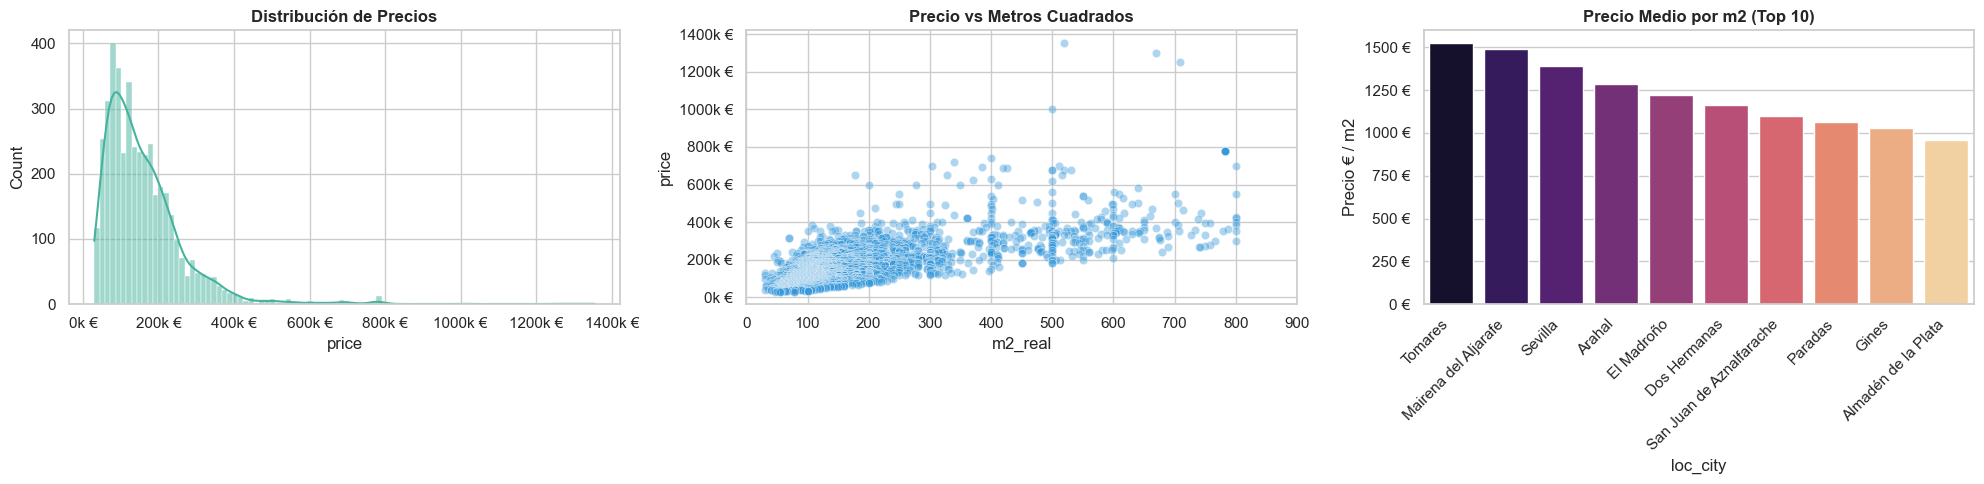

In [14]:
# Gráficos de distribución y relación entre variables clave

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. GRÁFICO IZQUIERDA: Distribución de Precios (Histograma)
sns.histplot(df_modelo['price'], kde=True, color='#45B39D', ax=axes[0])
axes[0].set_title('Distribución de Precios', fontweight='bold')
axes[0].set_xlabel('price')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 2. GRÁFICO CENTRO: Precio vs Metros Cuadrados (Scatter Plot)
sns.scatterplot(data=df_modelo, x='m2_real', y='price', alpha=0.4, color='#3498DB', ax=axes[1])
axes[1].set_title('Precio vs Metros Cuadrados', fontweight='bold')
axes[1].set_xlim(0, 900)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 3. GRÁFICO DERECHA: Precio Medio por m2 (Bar Plot - Top 10)
top_10_ciudades = df_modelo.groupby('loc_city')['price_m2'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])
axes[2].set_title('Precio Medio por m2 (Top 10)', fontweight='bold')
axes[2].set_ylabel('Precio € / m2')
axes[2].set_xlabel('loc_city')
axes[2].set_xticks(range(len(top_10_ciudades)))
axes[2].set_xticklabels(top_10_ciudades.index, rotation=45, ha='right')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)} €'))

plt.tight_layout()
plt.show()

Para cumplir con la interoperabilidad, en este paso construimos un puente entre Python y R. Usamos Python para extraer una muestra segura de 5000 viviendas (evitando así saturar la memoria del ordenador) y la exportamos a un archivo temporal. Luego, nuestro código rastrea automáticamente el sistema operativo en busca del motor de R y, de forma preventiva, comprueba que el programa existe antes de intentar inyectarle un script generado para dibujar un gráfico con ggplot2. Una vez que R hace su trabajo en segundo plano y Python recoge la imagen para mostrarla en pantalla, se ejecuta una rutina de limpieza automática que borra los archivos temporales para no ensuciar el disco duro.

'Rscript' no se encontró en el PATH. Usando ruta alternativa.


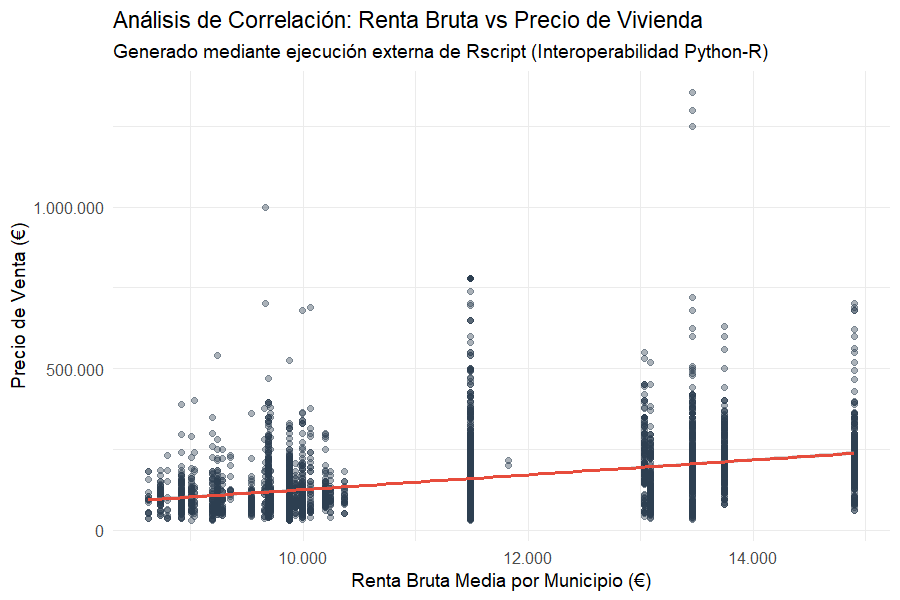

Integración Python-R completada


In [18]:
import pandas as pd
import subprocess
from IPython.display import Image, display
import os
import shutil

# INTEROPERABILIDAD CON R

# 1. Rutas absolutas automáticas
ruta_actual = os.getcwd()
ruta_csv = os.path.join(ruta_actual, 'datos_para_r.csv')
ruta_script = os.path.join(ruta_actual, 'script_viviendas.R')
ruta_img = os.path.join(ruta_actual, 'grafico_renta_precio.png')

# 2. Preparamos los datos temporales (Usamos muestra para no saturar R)
df_r = df_modelo[['renta_bruta_media', 'price']].dropna()
muestra = min(5000, len(df_r))
df_r.sample(muestra, random_state=42).to_csv(ruta_csv, index=False)

# R necesita las barras hacia la derecha (/) en las rutas de Windows
ruta_csv_r = ruta_csv.replace('\\', '/')
ruta_img_r = ruta_img.replace('\\', '/')

codigo_r = f"""
# Evitamos que R pregunte por el servidor al instalar y congele Python
options(repos = c(CRAN = "http://cran.us.r-project.org"))

if (!require("ggplot2", quietly = TRUE)) install.packages("ggplot2")
if (!require("scales", quietly = TRUE)) install.packages("scales")

library(ggplot2)
library(scales)

# Leemos el archivo usando la ruta absoluta que nos pasó Python
viviendas <- read.csv('{ruta_csv_r}')
colnames(viviendas) <- c("renta_bruta", "precio_vivienda") # Normalizamos para R

# Configuramos la imagen de salida
png('{ruta_img_r}', width=900, height=600, res=100)

# Creamos el gráfico
p <- ggplot(viviendas, aes(x=renta_bruta, y=precio_vivienda)) +
  geom_point(alpha=0.4, color="#2c3e50") +
  geom_smooth(method="lm", color="#e74c3c", se=TRUE) +
  theme_minimal(base_size=14) +
  labs(
    title="Análisis de Correlación: Renta Bruta vs Precio de Vivienda",
    subtitle="Generado mediante ejecución externa de Rscript (Interoperabilidad Python-R)",
    x="Renta Bruta Media por Municipio (€)",
    y="Precio de Venta (€)"
  ) +
  scale_y_continuous(labels = comma_format(big.mark = ".", decimal.mark = ",")) +
  scale_x_continuous(labels = comma_format(big.mark = ".", decimal.mark = ","))

print(p)
invisible(dev.off())
"""

# Guardamos el script en el disco duro temporalmente
with open(ruta_script, "w", encoding="utf-8") as f:
    f.write(codigo_r)

# Intentamos encontrar 'Rscript' automáticamente en el sistema
ruta_rscript = shutil.which("Rscript")

# Si el sistema no lo encuentra, usamos la ruta alternativa (Plan B)
if ruta_rscript is None:
    print("'Rscript' no se encontró en el PATH. Usando ruta alternativa.")
    # MODIFICAR ESTA RUTA SI EL EVALUADOR TIENE R EN OTRO DIRECTORIO
    ruta_rscript = r"C:\Program Files\R\R-4.5.1\bin\Rscript.exe" 

# Verificamos si R está instalado antes de intentar ejecutar nada
if not os.path.exists(ruta_rscript):
    print("R no está instalado o la ruta no es correcta. Saltando interoperabilidad con R.")
    print("Para habilitar esta funcionalidad, instala R desde https://cran.r-project.org/")
else:
    try:
        # Python llama al sistema operativo para que ejecute R
        resultado = subprocess.run([ruta_rscript, ruta_script], capture_output=True, text=True, check=True)
        
        # 4. Python recoge el resultado y lo muestra
        display(Image(filename=ruta_img))
        
        # 5. Limpieza automática
        if os.path.exists(ruta_csv): os.remove(ruta_csv)
        if os.path.exists(ruta_script): os.remove(ruta_script)
        
        print("Integración Python-R completada")
        
    except subprocess.CalledProcessError as e:
        print(f"Error interno de R al ejecutar el script:\n{e.stderr}")
    except Exception as e:
        print(f"Error inesperado: {e}")

En este paso se contruye una función recursiva programando un algoritmo que se llama a sí mismo repetidamente para encontrar el precio máximo dentro de una pequeña muestra de nuestras viviendas, dividiendo la lista paso a paso hasta llegar a su caso base.

In [16]:
# Uso de recursividad

# Implementamos una función recursiva para encontrar el valor máximo en una lista

def encontrar_maximo_recursivo(lista):

    # 1. Caso base: Si la lista solo tiene un elemento, ese es el máximo
    if len(lista) == 1:
        return lista[0]
    
    # 2. Paso recursivo: Separamos el primer elemento y buscamos el máximo del resto de la lista
    else:
        max_del_resto = encontrar_maximo_recursivo(lista[1:])
        
        # Devolvemos el mayor de los dos
        if lista[0] > max_del_resto:
            return lista[0]
        else:
            return max_del_resto

# Extraemos una muestra de 15 precios aleatorios del dataset ya limpio
# Lo convertimos a una lista estándar de Python para que la función recursiva pueda procesarla
muestra_precios = df_modelo['price'].sample(15, random_state=42).tolist()

# Llamamos a nuestra función recursiva
precio_max_recursivo = encontrar_maximo_recursivo(muestra_precios)

# Resultados
print("Muestra extraída para análisis recursivo:")
print(muestra_precios)
print(f"El precio máximo encontrado por la función recursiva es: {precio_max_recursivo} €")
# Comprobación con Pandas
print(f"Comprobación nativa (Pandas max): {max(muestra_precios)} €")

Muestra extraída para análisis recursivo:
[70000, 140000, 209900, 87000, 390000, 190000, 150000, 85425, 150990, 250000, 42900, 52600, 170000, 45000, 76000]
El precio máximo encontrado por la función recursiva es: 390000 €
Comprobación nativa (Pandas max): 390000 €


# PASO 6: GUARDADO DEL DATASET PROCESADO

Para cerrar esta fase, blindamos todo el trabajo exportando nuestro dataset final a un nuevo archivo en la carpeta de datos procesados. Al guardarlo, eliminamos el índice automático de Pandas para no introducir "ruido" matemático, y realizamos una última auditoría de los tipos de variables para confirmar que el formato es exactamente el que exige la máquina.

In [19]:
# 1. Definimos la ruta y el nombre del archivo
ruta_final = '../data/processed/viviendas_sevilla_limpio.csv'

# 2. Guardamos el DataFrame sin el índice de filas
df_modelo.to_csv(ruta_final, index=False)

print(f"El dataset ha sido blindado y guardado en: {ruta_final}")
print(f"Resumen final: {df_modelo.shape[0]} filas y {df_modelo.shape[1]} columnas.")

# 3. Pequeño vistazo a los tipos de datos finales antes de la IA
print("Tipos de datos finales en el dataset limpio:")
print(df_modelo.dtypes.value_counts())

El dataset ha sido blindado y guardado en: ../data/processed/viviendas_sevilla_limpio.csv
Resumen final: 4247 filas y 20 columnas.
Tipos de datos finales en el dataset limpio:
int64      13
string      3
float64     3
str         1
Name: count, dtype: int64
